### Task 2.1

In [52]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')
import os

OUTPUT_DIR = './outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Running in local environment (VS Code)")
print(f"Output directory: {OUTPUT_DIR}")



Running in local environment (VS Code)
Output directory: ./outputs


In [58]:
import pandas as pd
import os

# Check if file exists
filepath = '/Users/sanjana/Desktop/sc4020-project-2/data/disease_symptom/dataset.csv'
print(f"File exists: {os.path.exists(filepath)}")

df=pd.read_csv(filepath)

print("Shape of data",df.shape)

File exists: True
Shape of data (4920, 18)


In [59]:
# APRIORI ALGORITHM IMPLEMENTATION
# Agrawal, R., & Srikant, R. (1994). "Fast algorithms for mining association rules"


class AprioriAlgorithm:
    
    def __init__(self, min_support=0.1, min_confidence=0.5):
        """
        Initialize Apriori algorithm with parameters.
        
        Args:
            min_support (float): Minimum support threshold (0-1)
            min_confidence (float): Minimum confidence for association rules (0-1)
        """
        self.min_support = min_support
        self.min_confidence = min_confidence
        self.frequent_itemsets = {}
        self.association_rules = []
        
    def get_unique_items(self, transactions):
        
        unique_items = set()
        for transaction in transactions:
            for item in transaction:
                unique_items.add(frozenset([item]))
        return unique_items
    
    def calculate_support(self, itemset, transactions):
        
        count = 0
        for transaction in transactions:
            if itemset.issubset(transaction):
                count += 1
        support_ratio = count / len(transactions)
        return count, support_ratio
    
    def generate_candidates(self, prev_frequent_itemsets, k):
        
        candidates = set()
        n = len(prev_frequent_itemsets)
        
        # Join step: combine itemsets with k-2 common items
        for i in range(n):
            for j in range(i + 1, n):
                # Union of two k-1 itemsets
                candidate = prev_frequent_itemsets[i] | prev_frequent_itemsets[j]
                
                # Check if size is k (should have exactly k items)
                if len(candidate) == k:
                    candidates.add(candidate)
        
        return candidates
    
    def prune_candidates(self, candidates, prev_frequent_itemsets, k):
        
        pruned_candidates = set()
        
        for candidate in candidates:
            # Get all k-1 subsets
            subsets = [frozenset(s) for s in combinations(candidate, k - 1)]
            
            # Check if all subsets are frequent
            all_frequent = all(subset in prev_frequent_itemsets for subset in subsets)
            
            if all_frequent:
                pruned_candidates.add(candidate)
        
        return pruned_candidates
    
    def fit(self, transactions, verbose=True):
        
        # Convert transactions to list of sets
        transactions = [set(t) for t in transactions]
        n_transactions = len(transactions)
        
        if verbose:
            print(f"Running Apriori Algorithm")
            print(f"Total transactions: {n_transactions}")
            print(f"Minimum support: {self.min_support} ({int(self.min_support * n_transactions)} transactions)")
            print("=" * 60)
        
        # Initialize with 1-itemsets
        k = 1
        candidates = self.get_unique_items(transactions)
        frequent_itemsets_dict = {}
        
        while candidates:
            if verbose:
                print(f"\nIteration k={k}:")
                print(f"  Candidates: {len(candidates)}")
            
            # Calculate support for all candidates
            frequent_k_itemsets = []
            itemset_support = {}
            
            for itemset in candidates:
                count, support = self.calculate_support(itemset, transactions)
                
                if support >= self.min_support:
                    frequent_k_itemsets.append(itemset)
                    itemset_support[itemset] = {'count': count, 'support': support}
            
            if not frequent_k_itemsets:
                break
            
            frequent_itemsets_dict[k] = itemset_support
            
            if verbose:
                print(f"  Frequent itemsets: {len(frequent_k_itemsets)}")
            
            # Generate candidates for next iteration
            k += 1
            if k == 2:
                # For k=2, just combine all 1-itemsets
                candidates = set()
                items = list(frequent_k_itemsets)
                for i in range(len(items)):
                    for j in range(i + 1, len(items)):
                        candidates.add(items[i] | items[j])
            else:
                # For k>2, use the generate and prune method
                candidates = self.generate_candidates(frequent_k_itemsets, k)
                if k > 2:
                    prev_frequent_set = set(frequent_k_itemsets)
                    candidates = self.prune_candidates(candidates, prev_frequent_set, k)
        
        self.frequent_itemsets = frequent_itemsets_dict
        
        if verbose:
            print("\n" + "=" * 60)
            print("Apriori Algorithm Completed!")
            total_frequent = sum(len(itemsets) for itemsets in frequent_itemsets_dict.values())
            print(f"Total frequent itemsets found: {total_frequent}")
        
        return frequent_itemsets_dict
    
    def generate_association_rules(self, min_confidence=None, verbose=True):
        
        if min_confidence is None:
            min_confidence = self.min_confidence
        
        rules = []
        
        # Only generate rules from itemsets of size >= 2
        for k in range(2, max(self.frequent_itemsets.keys()) + 1):
            if k not in self.frequent_itemsets:
                continue
            
            for itemset, metrics in self.frequent_itemsets[k].items():
                items = list(itemset)
                
                # Generate all possible rules from this itemset
                for i in range(1, len(items)):
                    # Generate all antecedents of size i
                    for antecedent_tuple in combinations(items, i):
                        antecedent = frozenset(antecedent_tuple)
                        consequent = itemset - antecedent
                        
                        # Calculate confidence
                        # Confidence(A->B) = Support(A∪B) / Support(A)
                        antecedent_size = len(antecedent)
                        if antecedent_size in self.frequent_itemsets:
                            if antecedent in self.frequent_itemsets[antecedent_size]:
                                antecedent_support = self.frequent_itemsets[antecedent_size][antecedent]['support']
                                confidence = metrics['support'] / antecedent_support
                                
                                if confidence >= min_confidence:
                                    # Calculate lift
                                    consequent_size = len(consequent)
                                    if consequent_size in self.frequent_itemsets:
                                        if consequent in self.frequent_itemsets[consequent_size]:
                                            consequent_support = self.frequent_itemsets[consequent_size][consequent]['support']
                                            lift = confidence / consequent_support
                                        else:
                                            lift = None
                                    else:
                                        lift = None
                                    
                                    rules.append({
                                        'antecedent': antecedent,
                                        'consequent': consequent,
                                        'support': metrics['support'],
                                        'confidence': confidence,
                                        'lift': lift
                                    })
        
        self.association_rules = sorted(rules, key=lambda x: x['confidence'], reverse=True)
        
        if verbose:
            print(f"\nGenerated {len(self.association_rules)} association rules")
            print(f"Minimum confidence threshold: {min_confidence}")
        
        return self.association_rules



In [61]:
def load_disease_symptom_data(filepath):
    
    try:
        df = pd.read_csv(filepath)
        print(f"Dataset loaded successfully!")
        print(f"Shape: {df.shape}")
        print(f"\nColumns: {df.columns.tolist()}")
        return df
    except FileNotFoundError:
        print(f"Error: File '{filepath}' not found.")
        print("Please place the dataset CSV in the same directory as this script.")
        print("Or update the filepath in the main() function.")
        return None

In [43]:
def clean_symptoms(symptom):
    if pd.isna(symptom) or symptom == '' or symptom.strip() == '':
        return None
    
    # Convert to lowercase and strip whitespace
    symptom = str(symptom).lower().strip()
    
    # Remove special characters but keep underscores and hyphens
    symptom = symptom.replace('_', ' ')
    
    return symptom


In [ ]:
def normalize_symptom_synonyms(symptom):
    
    # Dictionary of common medical synonyms
    # Source: Common medical terminology standardization
    synonym_map = {
        'pyrexia': 'fever',
        'elevated temperature': 'fever',
        'high temperature': 'fever',
        'febrile': 'fever',
        
        'cephalalgia': 'headache',
        'head pain': 'headache',
        
        'dyspnea': 'breathlessness',
        'shortness of breath': 'breathlessness',
        
        'emesis': 'vomiting',
        'throwing up': 'vomiting',
        
        'diarrhea': 'diarrhoea',
        'loose stools': 'diarrhoea',
        
        'coughing': 'cough',
        'tussis': 'cough',
        
        'myalgia': 'muscle pain',
        'muscle ache': 'muscle pain',
        
        'arthralgia': 'joint pain',
        'joint ache': 'joint pain',
        
        'epistaxis': 'nosebleed',
        'nose bleeding': 'nosebleed',
    }
    
    return synonym_map.get(symptom, symptom)


In [46]:
def prepare_transactions(df, normalize_synonyms=True):
    
    transactions = []
    disease_names = []
    symptom_columns = [col for col in df.columns if col.startswith('Symptom')]
    
    print(f"Processing {len(df)} diseases with {len(symptom_columns)} symptom columns...")
    
    all_symptoms_count = defaultdict(int)
    
    for idx, row in df.iterrows():
        symptoms = []
        
        # Extract all symptoms for this disease
        for col in symptom_columns:
            symptom = clean_symptoms(row[col])
            
            if symptom is not None:
                if normalize_synonyms:
                    symptom = normalize_symptom_synonyms(symptom)
                
                symptoms.append(symptom)
                all_symptoms_count[symptom] += 1
        
        if symptoms:  # Only add if there are valid symptoms
            transactions.append(symptoms)
            disease_names.append(row['Disease'])
    
    # Calculate statistics
    symptom_stats = {
        'total_unique_symptoms': len(all_symptoms_count),
        'total_transactions': len(transactions),
        'avg_symptoms_per_disease': np.mean([len(t) for t in transactions]),
        'most_common_symptoms': sorted(all_symptoms_count.items(), 
                                       key=lambda x: x[1], reverse=True)[:20]
    }
    
    print(f"\nTransaction Preparation Complete:")
    print(f"  Total transactions (diseases): {len(transactions)}")
    print(f"  Unique symptoms: {len(all_symptoms_count)}")
    print(f"  Average symptoms per disease: {symptom_stats['avg_symptoms_per_disease']:.2f}")
    
    return transactions, disease_names, symptom_stats



In [47]:
def visualize_symptom_distribution(symptom_stats, top_n=20):
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Top symptoms bar chart
    symptoms, counts = zip(*symptom_stats['most_common_symptoms'][:top_n])
    axes[0].barh(range(len(symptoms)), counts, color='steelblue')
    axes[0].set_yticks(range(len(symptoms)))
    axes[0].set_yticklabels(symptoms)
    axes[0].set_xlabel('Frequency')
    axes[0].set_title(f'Top {top_n} Most Common Symptoms')
    axes[0].invert_yaxis()
    
    # Add counts on bars
    for i, count in enumerate(counts):
        axes[0].text(count, i, f' {count}', va='center')
    
    # Distribution histogram
    all_counts = [count for _, count in symptom_stats['most_common_symptoms']]
    axes[1].hist(all_counts, bins=20, color='coral', edgecolor='black')
    axes[1].set_xlabel('Frequency')
    axes[1].set_ylabel('Number of Symptoms')
    axes[1].set_title('Distribution of Symptom Frequencies')
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/symptom_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {OUTPUT_DIR}/symptom_distribution.png")


In [48]:
def visualize_frequent_itemsets(frequent_itemsets, top_n=15):
    
    # Collect all itemsets with support
    all_itemsets = []
    for k, itemsets_dict in frequent_itemsets.items():
        for itemset, metrics in itemsets_dict.items():
            all_itemsets.append({
                'itemset': ', '.join(sorted(itemset)),
                'size': k,
                'support': metrics['support'],
                'count': metrics['count']
            })
    
    # Sort by support
    all_itemsets = sorted(all_itemsets, key=lambda x: x['support'], reverse=True)[:top_n]
    
    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Top itemsets by support
    itemsets_labels = [item['itemset'][:50] + '...' if len(item['itemset']) > 50 
                       else item['itemset'] for item in all_itemsets]
    supports = [item['support'] for item in all_itemsets]
    colors = plt.cm.viridis([item['size'] / max([i['size'] for i in all_itemsets]) 
                             for item in all_itemsets])
    
    axes[0].barh(range(len(itemsets_labels)), supports, color=colors)
    axes[0].set_yticks(range(len(itemsets_labels)))
    axes[0].set_yticklabels(itemsets_labels, fontsize=8)
    axes[0].set_xlabel('Support')
    axes[0].set_title(f'Top {top_n} Frequent Symptom Combinations by Support')
    axes[0].invert_yaxis()
    
    # Itemsets by size
    size_counts = defaultdict(int)
    for itemset_dict in all_itemsets:
        size_counts[itemset_dict['size']] += 1
    
    sizes = sorted(size_counts.keys())
    counts = [size_counts[s] for s in sizes]
    
    axes[1].bar(sizes, counts, color='teal', edgecolor='black')
    axes[1].set_xlabel('Itemset Size (number of symptoms)')
    axes[1].set_ylabel('Number of Frequent Itemsets')
    axes[1].set_title('Distribution of Frequent Itemsets by Size')
    axes[1].set_xticks(sizes)
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/frequent_itemsets.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {OUTPUT_DIR}/frequent_itemsets.png")

In [73]:
def visualize_association_rules(rules, top_n=15):
    """
    Visualize top association rules as 4 SEPARATE plots.
    
    Args:
        rules (list): List of association rules
        top_n (int): Number of top rules to display
    """
    if not rules:
        print("No association rules to visualize.")
        return
    
    # Get top rules
    top_rules = rules[:top_n]
    
    
    # PLOT 1: Top Rules by Confidence
    plt.figure(figsize=(12, 8))
    
    rule_labels = [f"{', '.join(sorted(r['antecedent']))} → {', '.join(sorted(r['consequent']))}"[:70] 
                   for r in top_rules]
    confidences = [r['confidence'] for r in top_rules]
    
    plt.barh(range(len(rule_labels)), confidences, color='salmon')
    plt.yticks(range(len(rule_labels)), rule_labels, fontsize=9)
    plt.xlabel('Confidence', fontsize=12)
    plt.title(f'Top {top_n} Association Rules by Confidence', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.xlim([0, 1])
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/rules_by_confidence.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {OUTPUT_DIR}/rules_by_confidence.png")
    
    
    # PLOT 2: Support vs Confidence Scatter
    plt.figure(figsize=(10, 8))
    
    all_supports = [r['support'] for r in rules]
    all_confidences = [r['confidence'] for r in rules]
    
    plt.scatter(all_supports, all_confidences, alpha=0.6, color='purple', s=50, edgecolors='black', linewidth=0.5)
    plt.xlabel('Support', fontsize=12)
    plt.ylabel('Confidence', fontsize=12)
    plt.title('Association Rules: Support vs Confidence', fontsize=14, fontweight='bold')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/support_vs_confidence.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {OUTPUT_DIR}/support_vs_confidence.png")
    
    
    # PLOT 3: Lift Distribution
    plt.figure(figsize=(10, 8))
    
    all_lifts = [r['lift'] for r in rules if r['lift'] is not None]
    
    plt.hist(all_lifts, bins=20, color='green', edgecolor='black', alpha=0.7)
    plt.xlabel('Lift', fontsize=12)
    plt.ylabel('Number of Rules', fontsize=12)
    plt.title('Distribution of Lift Values', fontsize=14, fontweight='bold')
    plt.axvline(x=1, color='red', linestyle='--', linewidth=2, label='Lift = 1 (independence)')
    plt.legend(fontsize=11)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/lift_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {OUTPUT_DIR}/lift_distribution.png")
    
    
    # PLOT 4: Top Rules by Lift
    plt.figure(figsize=(12, 8))
    
    rules_with_lift = [r for r in rules if r['lift'] is not None]
    top_lift_rules = sorted(rules_with_lift, key=lambda x: x['lift'], reverse=True)[:top_n]
    
    lift_labels = [f"{', '.join(sorted(r['antecedent']))} → {', '.join(sorted(r['consequent']))}"[:70] 
                   for r in top_lift_rules]
    lifts = [r['lift'] for r in top_lift_rules]
    
    plt.barh(range(len(lift_labels)), lifts, color='orange')
    plt.yticks(range(len(lift_labels)), lift_labels, fontsize=9)
    plt.xlabel('Lift', fontsize=12)
    plt.title(f'Top {top_n} Association Rules by Lift', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.axvline(x=1, color='red', linestyle='--', alpha=0.5, linewidth=2)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/rules_by_lift.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {OUTPUT_DIR}/rules_by_lift.png")
    
    print(f"\n✅ All 4 plots saved successfully!")

In [74]:
def print_summary_statistics(frequent_itemsets, rules):
    
    print("\n" + "="*70)
    print("SUMMARY STATISTICS")
    print("="*70)
    
    # Frequent itemsets statistics
    print("\n📊 Frequent Itemsets:")
    total_itemsets = sum(len(itemsets) for itemsets in frequent_itemsets.values())
    print(f"  Total frequent itemsets: {total_itemsets}")
    
    for k in sorted(frequent_itemsets.keys()):
        print(f"  Size {k}: {len(frequent_itemsets[k])} itemsets")
    
    # Association rules statistics
    print(f"\n📈 Association Rules:")
    print(f"  Total rules generated: {len(rules)}")
    
    if rules:
        avg_confidence = np.mean([r['confidence'] for r in rules])
        avg_support = np.mean([r['support'] for r in rules])
        lifts = [r['lift'] for r in rules if r['lift'] is not None]
        avg_lift = np.mean(lifts) if lifts else 0
        
        print(f"  Average confidence: {avg_confidence:.4f}")
        print(f"  Average support: {avg_support:.4f}")
        print(f"  Average lift: {avg_lift:.4f}")
        
        # Top 5 rules
        print(f"\n🔝 Top 5 Rules by Confidence:")
        for i, rule in enumerate(rules[:5], 1):
            ant = ', '.join(rule['antecedent'])
            cons = ', '.join(rule['consequent'])
            print(f"  {i}. {ant} → {cons}")
            lift_str = f"{rule['lift']:.4f}" if rule['lift'] is not None else "N/A"
            print(f"Support: {rule['support']:.4f}, Confidence: {rule['confidence']:.4f}, Lift: {lift_str}")


In [51]:
def save_results_to_csv(frequent_itemsets, rules):
    
    # Save frequent itemsets
    itemsets_data = []
    for k, itemsets_dict in frequent_itemsets.items():
        for itemset, metrics in itemsets_dict.items():
            itemsets_data.append({
                'itemset': ', '.join(sorted(itemset)),
                'size': k,
                'support': metrics['support'],
                'count': metrics['count']
            })
    
    df_itemsets = pd.DataFrame(itemsets_data)
    df_itemsets = df_itemsets.sort_values('support', ascending=False)
    df_itemsets.to_csv(f'{OUTPUT_DIR}/frequent_itemsets.csv', index=False)
    print(f"\nSaved: {OUTPUT_DIR}/frequent_itemsets.csv")
    
    # Save association rules
    if rules:
        rules_data = []
        for rule in rules:
            rules_data.append({
                'antecedent': ', '.join(rule['antecedent']),
                'consequent': ', '.join(rule['consequent']),
                'support': rule['support'],
                'confidence': rule['confidence'],
                'lift': rule['lift']
            })
        
        df_rules = pd.DataFrame(rules_data)
        df_rules.to_csv(f'{OUTPUT_DIR}/association_rules.csv', index=False)
        print(f"Saved: {OUTPUT_DIR}/association_rules.csv")


TASK 2.1: ANALYSIS OF SYMPTOM CO-OCCURRENCE PATTERNS
Using Apriori Algorithm

 Step 1: Loading Dataset...
Dataset loaded successfully!
Shape: (4920, 18)

Columns: ['Disease', 'Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4', 'Symptom_5', 'Symptom_6', 'Symptom_7', 'Symptom_8', 'Symptom_9', 'Symptom_10', 'Symptom_11', 'Symptom_12', 'Symptom_13', 'Symptom_14', 'Symptom_15', 'Symptom_16', 'Symptom_17']

First few rows of the dataset:
            Disease   Symptom_1              Symptom_2              Symptom_3  \
0  Fungal infection     itching              skin_rash   nodal_skin_eruptions   
1  Fungal infection   skin_rash   nodal_skin_eruptions    dischromic _patches   
2  Fungal infection     itching   nodal_skin_eruptions    dischromic _patches   
3  Fungal infection     itching              skin_rash    dischromic _patches   
4  Fungal infection     itching              skin_rash   nodal_skin_eruptions   

              Symptom_4 Symptom_5 Symptom_6 Symptom_7 Symptom_8 Symptom_9  \


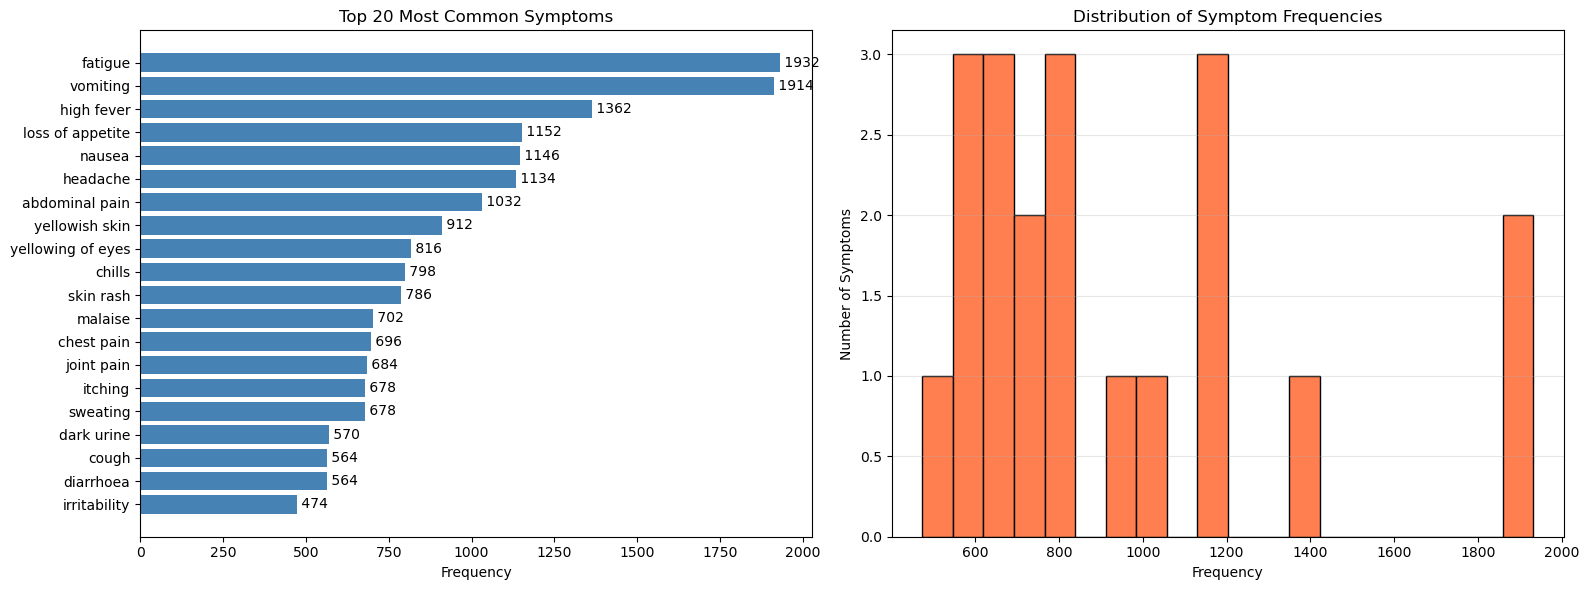

Saved: ./outputs/symptom_distribution.png

  Step 4: Running Apriori Algorithm...

You can adjust the minimum support threshold below:
Recommendation: Start with 0.1 (10%) and adjust based on results

Running Apriori Algorithm
Total transactions: 4920
Minimum support: 0.1 (492 transactions)

Iteration k=1:
  Candidates: 131
  Frequent itemsets: 19

Iteration k=2:
  Candidates: 171
  Frequent itemsets: 33

Iteration k=3:
  Candidates: 44
  Frequent itemsets: 19

Iteration k=4:
  Candidates: 2
  Frequent itemsets: 2

Apriori Algorithm Completed!
Total frequent itemsets found: 73

 Step 5: Visualizing Frequent Itemsets...


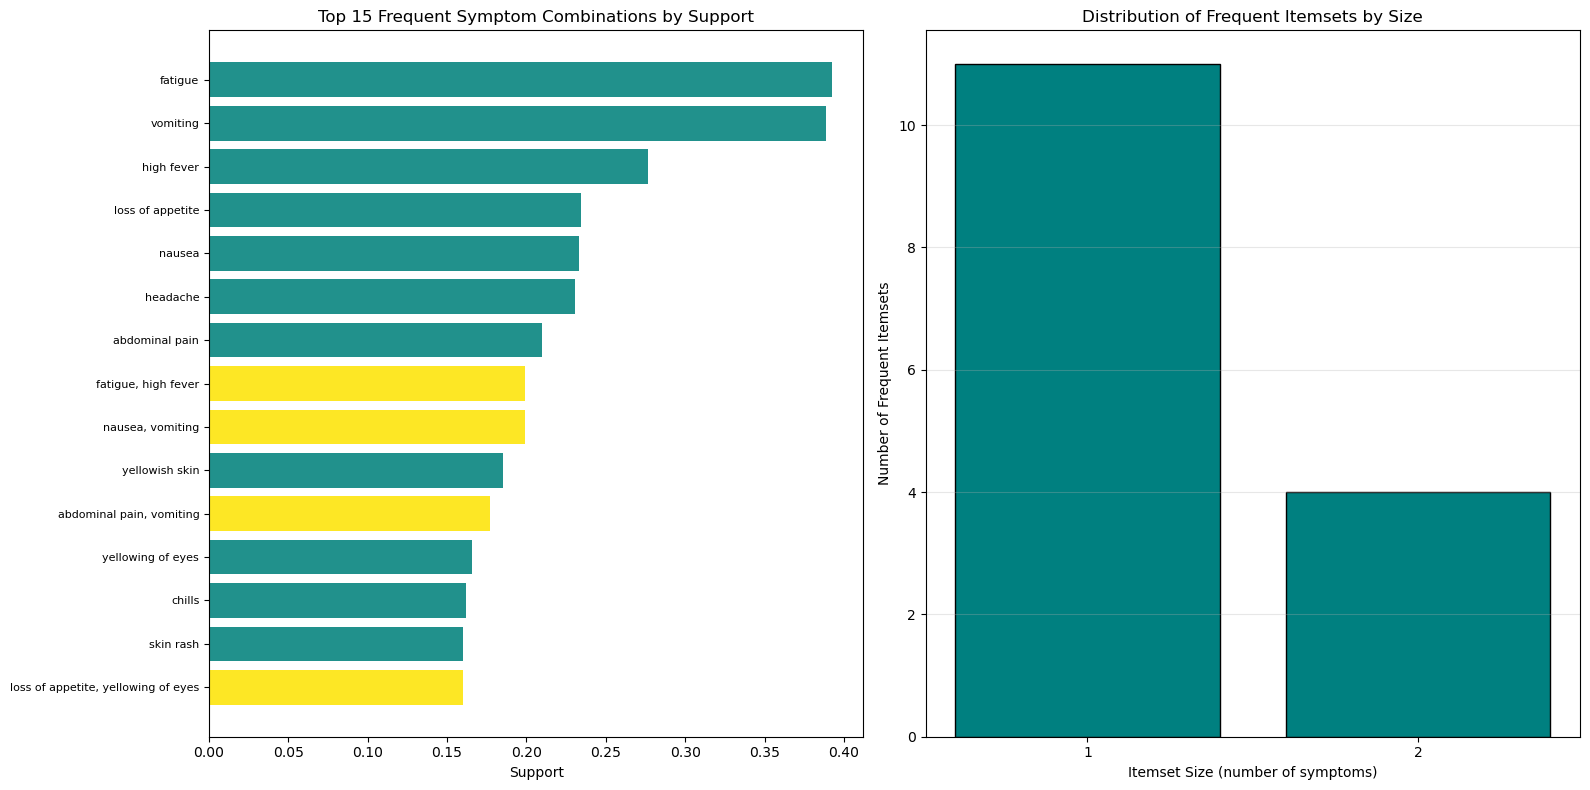

Saved: ./outputs/frequent_itemsets.png

 Step 6: Generating Association Rules...

Generated 145 association rules
Minimum confidence threshold: 0.5

 Step 7: Visualizing Association Rules...


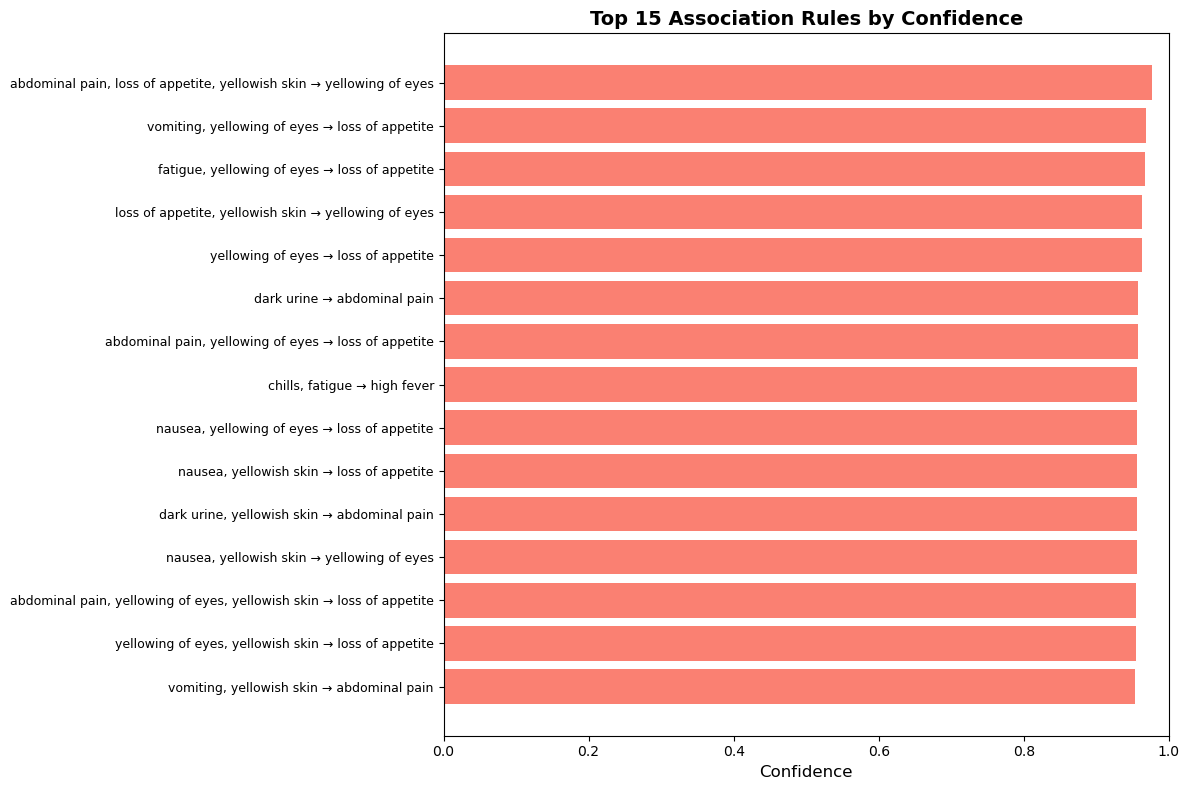

Saved: ./outputs/rules_by_confidence.png


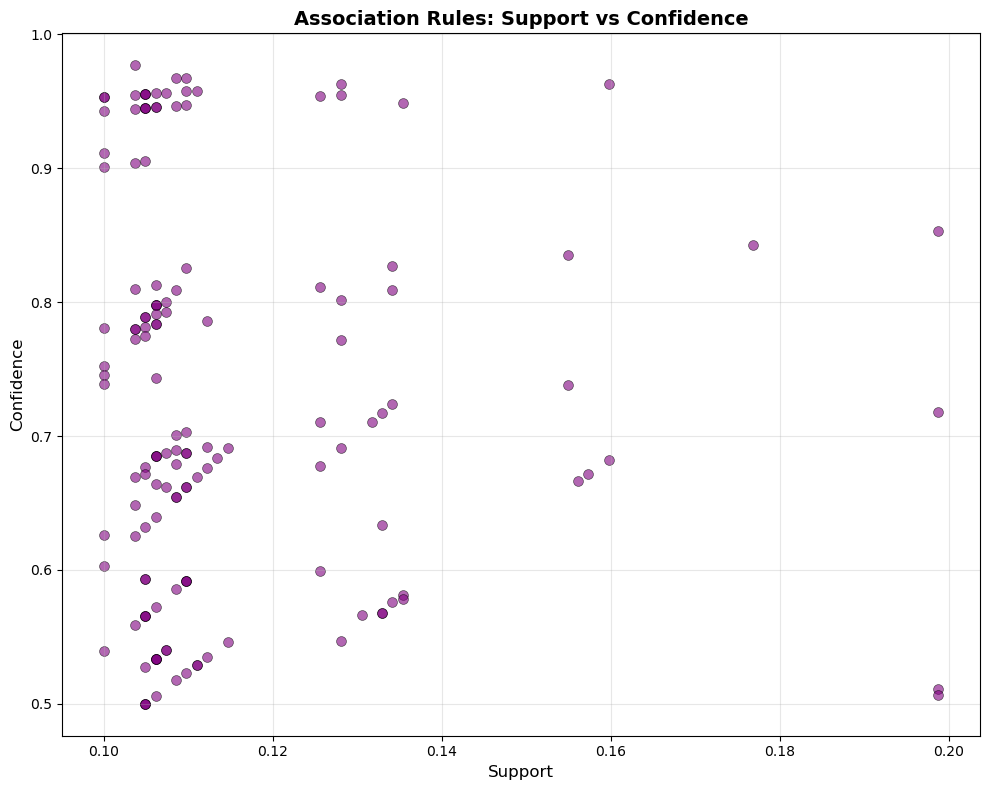

Saved: ./outputs/support_vs_confidence.png


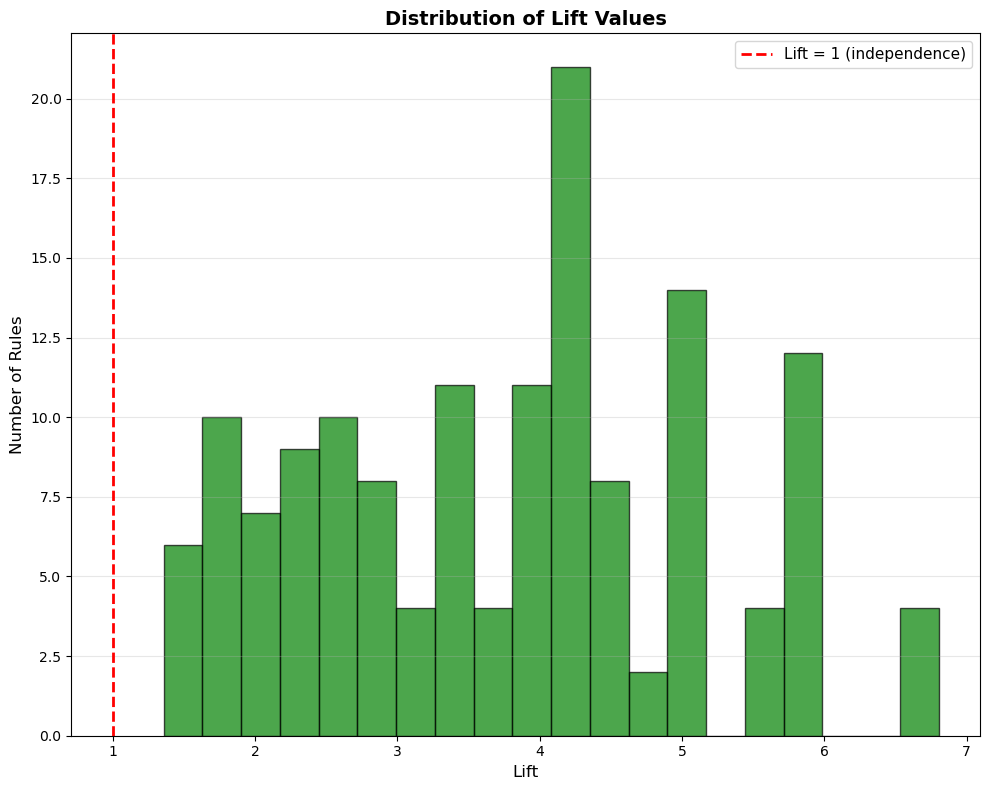

Saved: ./outputs/lift_distribution.png


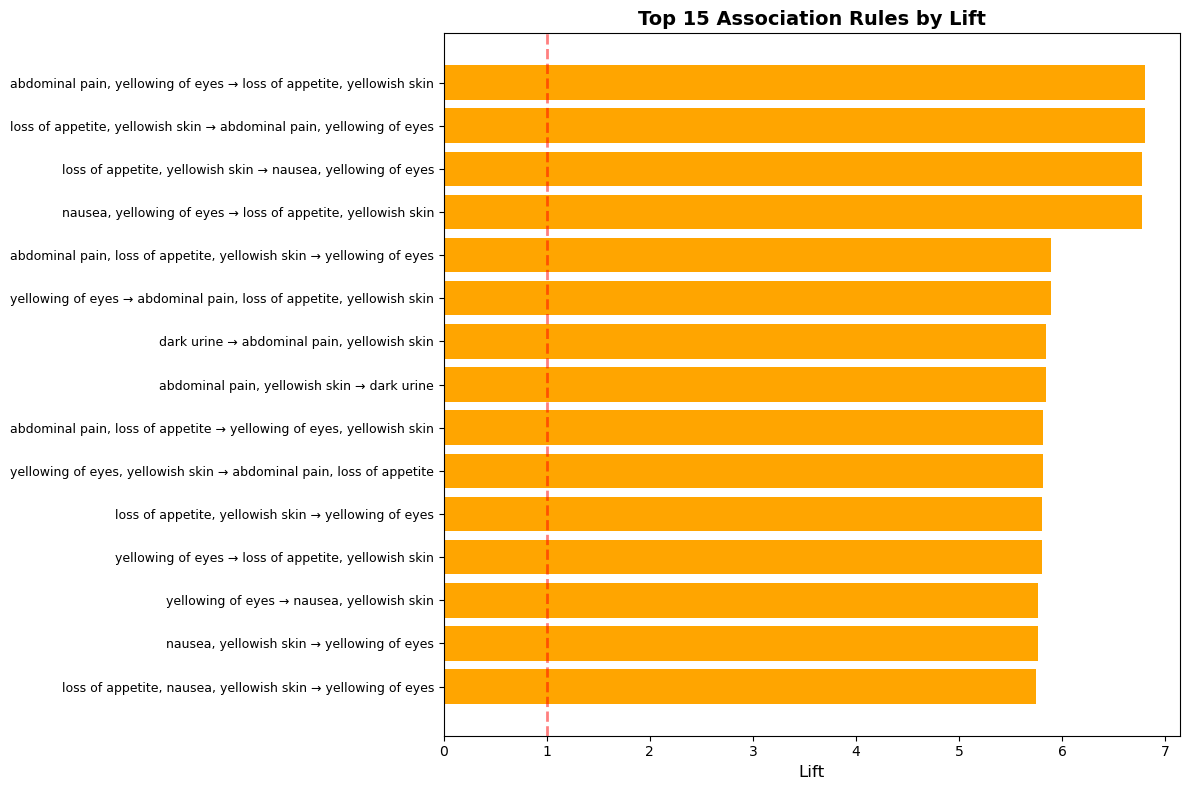

Saved: ./outputs/rules_by_lift.png

✅ All 4 plots saved successfully!

 Step 8: Saving Results...

SUMMARY STATISTICS

📊 Frequent Itemsets:
  Total frequent itemsets: 73
  Size 1: 19 itemsets
  Size 2: 33 itemsets
  Size 3: 19 itemsets
  Size 4: 2 itemsets

📈 Association Rules:
  Total rules generated: 145
  Average confidence: 0.7268
  Average support: 0.1154
  Average lift: 3.7394

🔝 Top 5 Rules by Confidence:
  1. loss of appetite, yellowish skin, abdominal pain → yellowing of eyes
Support: 0.1037, Confidence: 0.9770, Lift: 5.8908
  2. yellowing of eyes, vomiting → loss of appetite
Support: 0.1098, Confidence: 0.9677, Lift: 4.1331
  3. fatigue, yellowing of eyes → loss of appetite
Support: 0.1085, Confidence: 0.9674, Lift: 4.1316
  4. loss of appetite, yellowish skin → yellowing of eyes
Support: 0.1280, Confidence: 0.9633, Lift: 5.8081
  5. yellowing of eyes → loss of appetite
Support: 0.1598, Confidence: 0.9632, Lift: 4.1138

Saved: ./outputs/frequent_itemsets.csv
Saved: ./outputs/

In [75]:

# MAIN EXECUTION


def main():
    """
    Main execution function for Task 2.1
    """
    print("="*70)
    print("TASK 2.1: ANALYSIS OF SYMPTOM CO-OCCURRENCE PATTERNS")
    print("Using Apriori Algorithm")
    print("="*70)
    
    # Step 1: Load data
    print("\n Step 1: Loading Dataset...")
    
    # IMPORTANT: Update this path to your dataset location!
    # Options:
    # 1. If file is in same directory: 'dataset.csv'
    # 2. If in data folder: 'data/dataset.csv'
    # 3. Full path: 'C:/Users/YourName/Downloads/dataset.csv'
    
    
    df = load_disease_symptom_data(filepath)
    
    if df is None:
        print("\n Cannot proceed without dataset!")
        return
    
    print(f"\nFirst few rows of the dataset:")
    print(df.head())
    
    # Step 2: Prepare transactions
    print("\n Step 2: Preparing Transactions...")
    transactions, disease_names, symptom_stats = prepare_transactions(df, normalize_synonyms=True)
    
    # Visualize symptom distribution
    print("\n Step 3: Visualizing Symptom Distribution...")
    visualize_symptom_distribution(symptom_stats, top_n=20)
    
    # Step 3: Run Apriori Algorithm
    print("\n  Step 4: Running Apriori Algorithm...")
    print("\nYou can adjust the minimum support threshold below:")
    print("Recommendation: Start with 0.1 (10%) and adjust based on results\n")
    
    # Adjust these parameters as needed
    MIN_SUPPORT = 0.1      # 10% - adjust based on your dataset
    MIN_CONFIDENCE = 0.5   # 50% - adjust based on your requirements
    
    apriori = AprioriAlgorithm(min_support=MIN_SUPPORT, min_confidence=MIN_CONFIDENCE)
    frequent_itemsets = apriori.fit(transactions, verbose=True)
    
    # Step 4: Visualize frequent itemsets
    print("\n Step 5: Visualizing Frequent Itemsets...")
    visualize_frequent_itemsets(frequent_itemsets, top_n=15)
    
    # Step 5: Generate association rules
    print("\n Step 6: Generating Association Rules...")
    rules = apriori.generate_association_rules(min_confidence=MIN_CONFIDENCE, verbose=True)
    
    # Step 6: Visualize association rules
    if rules:
        print("\n Step 7: Visualizing Association Rules...")
        visualize_association_rules(rules, top_n=15)
    else:
        print("\n  No association rules found with current thresholds.")
        print("Try lowering min_confidence or min_support.")
    
    # Step 7: Print summary and save results
    print("\n Step 8: Saving Results...")
    print_summary_statistics(frequent_itemsets, rules)
    save_results_to_csv(frequent_itemsets, rules)
    
    print("\n" + "="*70)
    print(" TASK 2.1 COMPLETED SUCCESSFULLY!")
    print("="*70)
    print(f"\nGenerated files (in {OUTPUT_DIR}/):")
    print("  1. symptom_distribution.png")
    print("  2. frequent_itemsets.png")
    print("  3. association_rules.png")
    print("  4. frequent_itemsets.csv")
    print("  5. association_rules.csv")
    



if __name__ == "__main__":
    # Run main analysis
    main()
